# Lab 4 — Planning with a World Model (MPC / CEM)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/overdued/world-model-spatial-intelligence-course/blob/main/labs/lab04_mpc_cem_planning/notebook_en.ipynb)

**World Models & Spatial Intelligence · Hands-on Lab 4**

In the previous labs we learned to **build** a world (Lab 0), **estimate** its state (Lab 1), and **learn** latent dynamics (Labs 2 and 3). This lab answers the last key question: **once we have a world model, how do we use it for decision making?**

The answer is surprisingly simple. Since the model can "imagine" the future (`ŝ_{t+1} = f(ŝ_t, a_t)`), before taking any action we can **roll out** a large batch of candidate action sequences inside the model, rank them by predicted reward, execute only the first action of the best sequence, and replan at the next step. That is the core idea of **Model Predictive Control (MPC)**, and it is the shared decision-making backbone of modern methods such as PlaNet, PETS, TD-MPC and Dreamer.

In this lab you will:

1. Reuse the Moving-Ball World from Lab 0 and prepare **two dynamics models**: a vectorized analytic copy of the environment's dynamics (the perfect model, an upper bound on performance) and an MLP trained in under a minute inside the notebook (the learned model);
2. Hand-write two classic gradient-free planners: **Random Shooting MPC** and **CEM (Cross-Entropy Method)**;
3. See directly **how model error affects planning**. This is the key to understanding why model-based methods succeed or fail, and it sets up Lab 10.

## 1. Motivation: why can a world model be used for decision making?

In model-free RL, trial and error **really happens**: the agent has to actually take a step to find out whether it was a good one. With an accurate enough world model, trial and error can move into **imagination**:

- **Exploration at zero environment cost**: roll out ten thousand times in the model without taking a single real step;
- **Lookahead**: whether an action is good depends on the future it leads to, and only a model can answer that;
- **Plug and play**: the same dynamics model with a different reward solves a different task, without retraining any policy.

MPC does this with maximal simplicity: **replan at every step**, execute only the first action of the current best action sequence, observe the real world's feedback, and plan again. This **receding horizon** strategy keeps open-loop model error from dominating decisions, because every step restarts from the real state.

> **Core formula**: at the current state $s_t$, solve
> $$a_{t:t+H}^* = \arg\max_{a_{t:t+H}} \sum_{k=0}^{H-1} r(\hat{s}_{t+k+1}), \quad \hat{s}_{t+k+1} = f(\hat{s}_{t+k}, a_{t+k})$$
> Execute only $a_t^*$, discard the rest, and solve again at the next step.
>
> Different planners are just different approximations of this argmax: **random shooting** samples uniformly, **CEM** uses a Gaussian sampling distribution that shrinks iteratively. Both are gradient-free, so the model does not need to be differentiable.

## 2. Setup

This notebook is fully self-contained: it runs as-is on Colab or locally, and all experiments (training + planning + comparisons) finish on CPU within a few minutes. The cell below is the same as in Labs 0–3: it checks/installs dependencies and fixes the random seeds.

In [1]:
# @title setup
import sys, subprocess

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for pkg in ["torch", "matplotlib"]:
    ensure(pkg)

import os
import time
import platform
import resource
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

%matplotlib inline
os.makedirs("assets", exist_ok=True)

SEED = 0
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
T0 = time.time()  # timer start: the last experiment cell reports total runtime and peak memory
print("torch", torch.__version__, "| numpy", np.__version__)

torch 2.14.0+cu130 | numpy 2.4.6


## 3. Environment & Dataset

### 3.1 Environment: Moving-Ball World (reused from Lab 0)

We reuse the Lab 0 environment in full, only with a "gentler" set of physical parameters (`friction=0.9, force_scale=1.0`) so the ball's speed suits short-horizon planning:

- **State** `s = (x, y, vx, vy)`: the ball's position and velocity inside the unit square;
- **Action** `a = (ax, ay) ∈ [-1, 1]²`: a 2-D continuous force (continuous actions make Gaussian sampling in CEM easy; the environment's `step` already accepts non-scalar actions);
- **Transition**: semi-implicit Euler (update velocity first, then position) + inelastic wall bounce + friction;
- **Reward** `r = -||p_ball − p_goal||`: the closer to the goal, the higher the reward; the episode ends early (done) when the distance is < 0.05.

### 3.2 Two dynamics models

Planning needs a function that answers `s_{t+1} = f(s_t, a_t)`. We prepare two:

1. **Perfect model (analytic)**: the environment's transition rewritten in vectorized form. It is the "god's-eye" upper bound: it tells you how good the planning algorithm itself is;
2. **Learned model**: a plain MLP that takes `(s_t, a_t)` and outputs `Δs = s_{t+1} − s_t` (the residual form is easier to learn), trained entirely on random rollouts from the environment (next section).

The cell below defines the environment and the vectorized analytic dynamics, and runs a **unit-test-style self-check**: for a random batch of states/actions, the analytic model's output must match the environment's `step` exactly. Otherwise the "perfect model" would not deserve its name.

In [2]:
PARAMS = dict(size=64, dt=0.1, friction=0.9, bounce=0.8, force_scale=1.0, obs_noise=0.5)

class MovingBallWorld:
    # the same Moving-Ball World as Lab 0; action accepts 9 discrete indices or a continuous (ax, ay)
    ACTION_TABLE = [(ax, ay) for ax in (-1, 0, 1) for ay in (-1, 0, 1)]

    def __init__(self, size=64, dt=0.1, friction=0.98, bounce=0.8,
                 force_scale=2.0, obs_noise=0.5, seed=None):
        self.size = size
        self.dt = dt
        self.friction = friction
        self.bounce = bounce
        self.force_scale = force_scale
        self.obs_noise = obs_noise
        self.rng = np.random.default_rng(seed)
        self.state = None             # (x, y, vx, vy), normalized coordinates
        self.goal = None              # (gx, gy)

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        margin = 0.15
        x, y = self.rng.uniform(margin, 1 - margin, size=2)
        self.state = np.array([x, y, 0.0, 0.0])
        self.goal = self.rng.uniform(margin, 1 - margin, size=2)
        return self.observe()

    def step(self, action):
        ax, ay = self.ACTION_TABLE[action] if np.isscalar(action) else action
        x, y, vx, vy = self.state

        # semi-implicit Euler: velocity first (force + friction), then position
        vx = (vx + self.force_scale * ax * self.dt) * self.friction
        vy = (vy + self.force_scale * ay * self.dt) * self.friction
        x = x + vx * self.dt
        y = y + vy * self.dt

        # inelastic wall bounce: reflect position, flip + damp velocity
        if x < 0: x, vx = -x, -vx * self.bounce
        if x > 1: x, vx = 2 - x, -vx * self.bounce
        if y < 0: y, vy = -y, -vy * self.bounce
        if y > 1: y, vy = 2 - y, -vy * self.bounce

        self.state = np.array([x, y, vx, vy])
        reward = -float(np.linalg.norm(self.state[:2] - self.goal))
        done = reward > -0.05  # close enough to the goal
        return self.observe(), reward, done, {"state": self.state.copy()}

    def observe(self):
        noise = self.rng.normal(0.0, self.obs_noise / self.size, size=2)
        return {"position": self.state[:2] + noise, "image": self.render()}

    def render(self):
        img = np.zeros((self.size, self.size, 3), dtype=np.uint8)
        px = int(np.clip(self.state[0], 0, 1) * (self.size - 1))
        py = int(np.clip(self.state[1], 0, 1) * (self.size - 1))
        yy, xx = np.mgrid[0:self.size, 0:self.size]
        ball = (xx - px) ** 2 + (yy - py) ** 2 <= 3 ** 2
        img[ball] = [255, 255, 255]
        gx = int(self.goal[0] * (self.size - 1))
        gy = int(self.goal[1] * (self.size - 1))
        img[max(gy - 1, 0):gy + 2, max(gx - 1, 0):gx + 2] = [255, 0, 0]
        return img


def analytic_step_np(states, actions, dt, friction, bounce, force_scale):
    """An exact vectorized replica of the MovingBallWorld.step dynamics.

    states: (..., 4), actions: (..., 2) -> next states (..., 4)
    Line-by-line equivalent to step above, with np.where writing the wall bounce in vector form.
    """
    x, y, vx, vy = np.moveaxis(np.asarray(states, dtype=np.float64), -1, 0)
    ax, ay = np.moveaxis(np.asarray(actions, dtype=np.float64), -1, 0)

    vx = (vx + force_scale * ax * dt) * friction
    vy = (vy + force_scale * ay * dt) * friction
    x = x + vx * dt
    y = y + vy * dt

    lo = x < 0; x = np.where(lo, -x, x); vx = np.where(lo, -vx * bounce, vx)
    hi = x > 1; x = np.where(hi, 2 - x, x); vx = np.where(hi, -vx * bounce, vx)
    lo = y < 0; y = np.where(lo, -y, y); vy = np.where(lo, -vy * bounce, vy)
    hi = y > 1; y = np.where(hi, 2 - y, y); vy = np.where(hi, -vy * bounce, vy)
    return np.stack([x, y, vx, vy], axis=-1)


# self-check: the analytic model must match the environment's step exactly (this is where the "perfect" in perfect model comes from)
chk = MovingBallWorld(**PARAMS, seed=123)
test_rng = np.random.default_rng(0)
max_err = 0.0
for _ in range(200):
    chk.reset()
    a = test_rng.uniform(-1, 1, size=2)
    s_before = chk.state.copy()
    _, _, _, info = chk.step(a)
    s_analytic = analytic_step_np(s_before[None], a[None], PARAMS["dt"], PARAMS["friction"],
                                  PARAMS["bounce"], PARAMS["force_scale"])[0]
    max_err = max(max_err, float(np.abs(info["state"] - s_analytic).max()))
print(f"self-check passed: max |analytic - env| = {max_err:.2e}  (200 random transitions)")

self-check passed: max |analytic - env| = 0.00e+00  (200 random transitions)


### 3.3 Dataset: generating transitions from random rollouts

The learned model is trained on `(s_t, a_t) → s_{t+1}` transition triples produced by a **purely random policy** (uniformly sampled continuous actions) interacting with the environment. This is the classic starting point of model-based RL: no intelligent behavior is needed, data from "wandering around" is enough to learn usable dynamics. Think of Dreamer's seed episodes.

Note a property of this data distribution: with random actions the ball spends a lot of time bouncing near the walls, which actually gives good coverage of the discontinuous dynamics at the walls.

**A deliberate choice**: we train on only **60 episodes (about 1.4k transitions)**, so data is not plentiful. This is not laziness but teaching design: we *want* the learned model to have clearly visible errors, so that in later experiments you can watch "model error → planning failure" happen with your own eyes. Scarce data is the number-one reason real-world models are imperfect.

collected 1475 transitions from 60 random episodes in 0.1s


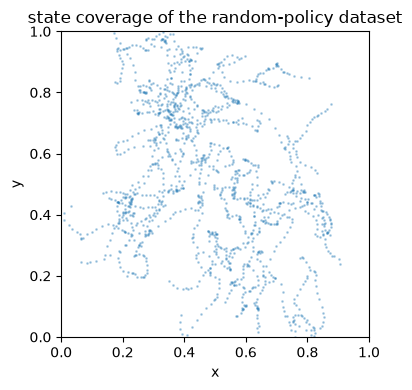

In [3]:
N_EP, EP_LEN = 60, 25  # deliberately small dataset: keeps visible errors in the learned model
collect_env = MovingBallWorld(**PARAMS, seed=0)
data_rng = np.random.default_rng(1)

S, A, S2 = [], [], []
t0 = time.time()
for ep in range(N_EP):
    collect_env.reset()
    for t in range(EP_LEN):
        a = data_rng.uniform(-1.0, 1.0, size=2)
        s_prev = collect_env.state.copy()
        _, _, done, info = collect_env.step(a)
        S.append(s_prev)
        A.append(a)
        S2.append(info["state"].copy())
        if done:
            break

S = np.array(S, dtype=np.float32)
A = np.array(A, dtype=np.float32)
S2 = np.array(S2, dtype=np.float32)
print(f"collected {len(S)} transitions from {N_EP} random episodes in {time.time() - t0:.1f}s")

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(S[:, 0], S[:, 1], s=1, alpha=0.3)
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="x", ylabel="y",
       title="state coverage of the random-policy dataset")
plt.tight_layout()
plt.show()

## 4. Build the Model

### 4.1 Dynamics model: one interface for perfect and learned

**Why predict `Δs` instead of `s_{t+1}` directly?** The state changes very little within one step, so the identity is a very strong prior; residual prediction lets the network learn only the "change", which trains faster and more stably. This matches the practice of deep dynamics models such as PETS.

The cell below also defines the most important piece of infrastructure in this lab, a unified **batched rollout interface**:

```
rollout_model(step_fn, s0, goal, actions)  # actions: (N, H, 2)
    -> returns (N,), positions (N, H, 2)
```

Given any step function (analytic or learned), an initial state, a goal, and N candidate action sequences of length H, it rolls them all out in parallel and returns each candidate's cumulative predicted reward and position trajectory. **The planners only talk to this interface, so swapping the model never requires changing a planner.** That is the modularity that makes model-based methods attractive.

In [4]:
def reward_np(states, goal):
    """r = -||pos - goal||; states (..., 4) -> (...,)"""
    return -np.linalg.norm(states[..., :2] - np.asarray(goal), axis=-1)


def make_perfect_step(params):
    dt, fr, bo, fs = params["dt"], params["friction"], params["bounce"], params["force_scale"]
    def step(states, actions):
        return analytic_step_np(states, actions, dt, fr, bo, fs)
    return step


class DynamicsMLP(nn.Module):
    """(s_t, a_t) -> s_{t+1}, residual form: the network only predicts Δs."""
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 4))

    def forward(self, s, a):
        return s + self.net(torch.cat([s, a], dim=-1))


model = DynamicsMLP(hidden=128)


def learned_step(states, actions):
    """learned dynamics with a numpy interface (torch inside, no_grad)."""
    with torch.no_grad():
        s = torch.as_tensor(np.asarray(states), dtype=torch.float32)
        a = torch.as_tensor(np.asarray(actions), dtype=torch.float32)
        return model(s, a).numpy()


perfect_step = make_perfect_step(PARAMS)


def rollout_model(step_fn, s0, goal, actions):
    """unified batched rollout: actions (N, H, 2) -> returns (N,), positions (N, H, 2)"""
    n, horizon, _ = actions.shape
    states = np.repeat(np.asarray(s0, dtype=np.float64)[None], n, axis=0)
    positions = np.empty((n, horizon, 2))
    returns = np.zeros(n)
    for t in range(horizon):
        states = step_fn(states, actions[:, t])
        positions[:, t] = states[:, :2]
        returns += reward_np(states, goal)
    return returns, positions


print("dynamics + rollout interface ready;",
      f"model params: {sum(p.numel() for p in model.parameters())}")

dynamics + rollout interface ready; model params: 17924


### 4.2 Two planners (the core algorithms, written out by hand)

**Random Shooting MPC**: the simplest trajectory optimization:

1. Sample N action sequences of length H from a uniform distribution;
2. Roll each one out in the model and compute its cumulative predicted reward;
3. Execute the **first action** of the best sequence and replan at the next step (receding horizon).

**CEM (Cross-Entropy Method)**: turns the sampling distribution itself into the object being optimized:

1. Maintain a Gaussian $\mathcal{N}(\mu, \sigma^2)$ over action sequences, where $\mu, \sigma$ both have shape `(H, 2)`;
2. Sample N candidates → roll out and score → keep the highest-scoring **elite** subset;
3. Re-estimate $\mu$ and $\sigma$ from the elites (the distribution shrinks toward good solutions), and iterate for a few rounds;
4. Execute the first action of the final mean sequence.

Intuitive comparison: random shooting "casts a fresh net" at every step; CEM "casts, hauls in, and casts again", and usually finds better action sequences for the same sample budget. Both are **gradient-free**, so the model does not have to be differentiable. That is an important difference from the Dreamer-style route of backpropagating through imagination.

In [5]:
def mpc_random_shooting(step_fn, state, goal, horizon, n_samples, rng):
    """Random Shooting MPC: uniform sampling -> score by rollout -> return the first action of the best sequence."""
    actions = rng.uniform(-1.0, 1.0, size=(n_samples, horizon, 2))
    returns, positions = rollout_model(step_fn, state, goal, actions)
    best = int(np.argmax(returns))
    return actions[best, 0], {"actions": actions, "returns": returns,
                              "positions": positions, "best": best}


def cem_planner(step_fn, state, goal, horizon, n_samples, rng,
                n_iter=4, elite_frac=0.1, init_std=0.5, alpha=0.9):
    """CEM: maintain a Gaussian over action sequences; iteratively update its mean and std from the elites."""
    mean = np.zeros((horizon, 2))
    std = np.full((horizon, 2), init_std)
    n_elite = max(2, int(n_samples * elite_frac))
    actions = returns = positions = None
    for it in range(n_iter):
        eps = rng.standard_normal((n_samples, horizon, 2))
        actions = np.clip(mean + std * eps, -1.0, 1.0)
        returns, positions = rollout_model(step_fn, state, goal, actions)
        elites = actions[np.argsort(returns)[-n_elite:]]
        # soft update: shrink the distribution toward the elites, keeping a bit of the old one to avoid premature convergence
        mean = alpha * elites.mean(axis=0) + (1 - alpha) * mean
        std = alpha * elites.std(axis=0) + (1 - alpha) * std + 1e-3
    best = int(np.argmax(returns))
    return mean[0], {"actions": actions, "returns": returns,
                     "positions": positions, "best": best, "mean": mean}


# smoke test: both planners should return a valid 2-D action
_env = MovingBallWorld(**PARAMS)
_env.reset(seed=0)
a_mpc, _ = mpc_random_shooting(perfect_step, _env.state, _env.goal, horizon=8, n_samples=64, rng=rng)
a_cem, _ = cem_planner(perfect_step, _env.state, _env.goal, horizon=8, n_samples=64, rng=rng)
print("MPC first action:", np.round(a_mpc, 3), "| CEM first action:", np.round(a_cem, 3))

MPC first action: [-0.901 -0.467] | CEM first action: [-0.744 -0.468]


## 5. Train the Learned Dynamics

Standard supervised learning: minibatch MSE on `Δs`, Adam, under a minute on CPU. The training loss drops quickly but **does not reach zero**: at a wall bounce the velocity flips instantly, a nearly discontinuous dynamics that an MLP can only "smooth" into a soft transition. Keep this in mind, because it has visible consequences in the planning experiments later.

step  400/2000  MSE 1.04e-05


step  800/2000  MSE 7.38e-05


step 1200/2000  MSE 8.72e-06


step 1600/2000  MSE 2.82e-06


step 2000/2000  MSE 2.93e-06
trained in 282.5s on CPU


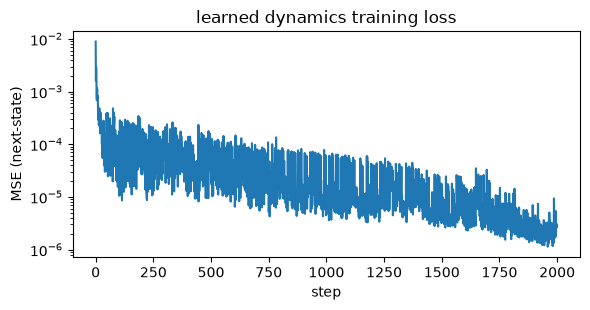

In [6]:
S_t = torch.from_numpy(S)
A_t = torch.from_numpy(A)
S2_t = torch.from_numpy(S2)

opt = torch.optim.Adam(model.parameters(), lr=3e-3)
mse = nn.MSELoss()

BATCH, STEPS = 256, 2000
losses = []
t0 = time.time()
for step in range(STEPS):
    idx = rng.choice(len(S_t), size=BATCH, replace=False)
    loss = mse(model(S_t[idx], A_t[idx]), S2_t[idx])
    opt.zero_grad()
    loss.backward()
    opt.step()
    losses.append(loss.item())
    if (step + 1) % 400 == 0:
        print(f"step {step + 1:4d}/{STEPS}  MSE {loss.item():.2e}")

model.eval()
print(f"trained in {time.time() - t0:.1f}s on CPU")

plt.figure(figsize=(6, 3.2))
plt.plot(losses)
plt.xlabel("step")
plt.ylabel("MSE (next-state)")
plt.yscale("log")
plt.title("learned dynamics training loss")
plt.tight_layout()
plt.savefig("assets/training_loss.png", dpi=130)
plt.show()

### 5.1 Model quality check: error accumulation in open-loop rollouts

A low one-step MSE **does not mean** the model is usable over many steps: its own predictions become the next step's input, so errors compound like interest (compounding error). Here we run a check similar to Lab 2's "dreaming": fix an initial state and an action sequence, then do a **40-step open-loop rollout** with both the perfect and the learned model (no real feedback in between), and compare the position trajectories and the per-step error.

**Expectation**: the first few steps almost coincide, then the trajectories drift apart, and the error often jumps at the moment of a wall hit. This "drift curve" is the microscopic explanation of the planning failures later on.

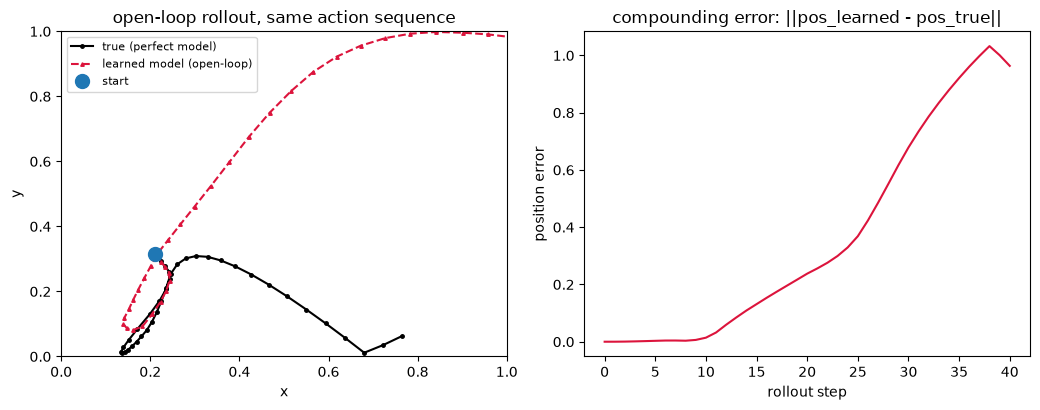

position error: 1-step 0.0001  ->  40-step 0.9635


In [7]:
H_CHECK = 40
chk_env = MovingBallWorld(**PARAMS)
chk_env.reset(seed=3)
s0 = chk_env.state.copy()
chk_rng = np.random.default_rng(0)
# random force that changes direction every 5 steps, producing rich dynamics with acceleration and wall hits
seq = chk_rng.uniform(-1, 1, size=(H_CHECK // 5, 2)).repeat(5, axis=0)

true_states = np.zeros((H_CHECK + 1, 4))
learned_states = np.zeros((H_CHECK + 1, 4))
true_states[0] = learned_states[0] = s0
s_true, s_learn = s0.copy(), s0.copy()
for t in range(H_CHECK):
    s_true = perfect_step(s_true[None], seq[t][None])[0]
    s_learn = learned_step(s_learn[None], seq[t][None])[0]
    true_states[t + 1], learned_states[t + 1] = s_true, s_learn

err = np.linalg.norm(true_states[:, :2] - learned_states[:, :2], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].plot(true_states[:, 0], true_states[:, 1], "-o", ms=2.5, color="black",
             label="true (perfect model)")
axes[0].plot(learned_states[:, 0], learned_states[:, 1], "--^", ms=2.5, color="crimson",
             label="learned model (open-loop)")
axes[0].plot(*s0[:2], "o", ms=10, color="tab:blue", label="start")
axes[0].set(xlim=(0, 1), ylim=(0, 1), xlabel="x", ylabel="y",
            title="open-loop rollout, same action sequence")
axes[0].legend(fontsize=8)
axes[1].plot(err, color="crimson")
axes[1].set(xlabel="rollout step", ylabel="position error",
            title="compounding error: ||pos_learned - pos_true||")
plt.tight_layout()
plt.savefig("assets/model_rollout_error.png", dpi=130)
plt.show()
print(f"position error: 1-step {err[1]:.4f}  ->  40-step {err[-1]:.4f}")

## 6. Visualize: what is the planner "thinking"?

Planning is a "sample → evaluate" process, and the most intuitive picture is a **fan plot of candidate trajectories**: at the current state, the hundreds of candidates the planner samples are drawn in translucent blue and the highest-scoring one is highlighted in red. You can see directly:

1. Which futures the sampling distribution covers: most candidates diffuse near the start like Brownian motion, and only a few sequences whose directions "happen to agree" get far;
2. How the best candidate stands out from the noise and heads straight for the goal;
3. Why too short a horizon fails: the fan never reaches the goal, so the reward carries no "go toward the goal" signal.

Below we plan once from a fixed initial state with **perfect model + random shooting** (H=25, N=800) and draw the fan plot.

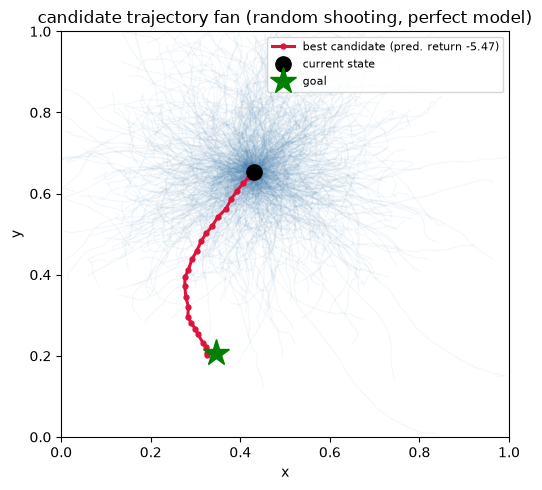

chosen first action: [-0.64  -0.293] -> execute this, then replan


In [8]:
fan_env = MovingBallWorld(**PARAMS)
fan_env.reset(seed=18)

action0, info = mpc_random_shooting(perfect_step, fan_env.state, fan_env.goal,
                                    horizon=25, n_samples=800, rng=rng)
pos, rets, best = info["positions"], info["returns"], info["best"]

fig, ax = plt.subplots(figsize=(5.4, 5))
for i in range(len(pos)):
    ax.plot(pos[i, :, 0], pos[i, :, 1], color="steelblue", alpha=0.06, lw=0.9, zorder=1)
ax.plot(pos[best, :, 0], pos[best, :, 1], "-o", color="crimson", ms=3.5, lw=2.2, zorder=3,
        label=f"best candidate (pred. return {rets[best]:.2f})")
ax.plot(*fan_env.state[:2], "o", color="black", ms=11, label="current state", zorder=4)
ax.plot(*fan_env.goal, "*", color="green", ms=20, label="goal", zorder=4)
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="x", ylabel="y",
       title="candidate trajectory fan (random shooting, perfect model)")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("assets/candidate_fan.png", dpi=130)
plt.show()
print("chosen first action:", np.round(action0, 3), "-> execute this, then replan")

### 6.1 Predicted vs Actual: the gap between imagination and reality

Now switch to the **learned model**, run a full MPC episode, and record the future trajectory the planner considered "best" at t=0. When the episode ends, plot this **imagined trajectory** together with the **trajectory actually traveled**:

- If the model were perfect, the two would coincide;
- In practice they separate: the planner's "promise" cannot be fully kept, because it is based on a world model with errors.

This is "model error → planning failure" in its most intuitive form. Fortunately, MPC's replanning restarts from the real state at every step, which makes it naturally robust to such errors. But robust does not mean immune (see the horizon experiment in Section 8).

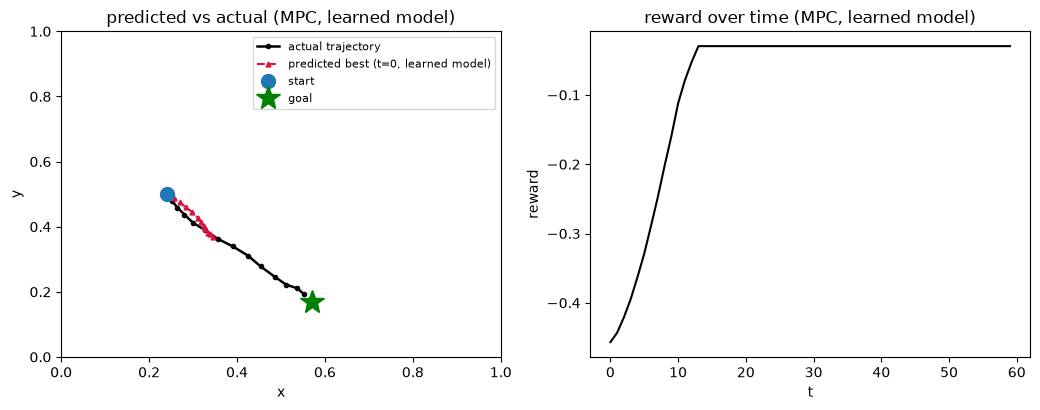

episode return: -4.94  (14 steps executed)


In [9]:
T_EP = 60
H_PLAN, N_SAMPLES = 12, 256

demo_env = MovingBallWorld(**PARAMS)
demo_env.reset(seed=11)
LOG_T = 0

actual = [demo_env.state[:2].copy()]
rewards_ep = []
predicted = None
for t in range(T_EP):
    a, info = mpc_random_shooting(learned_step, demo_env.state, demo_env.goal,
                                  H_PLAN, N_SAMPLES, rng)
    if t == LOG_T:
        predicted = info["positions"][info["best"]].copy()
    _, r, done, inf = demo_env.step(a)
    rewards_ep.append(r)
    actual.append(inf["state"][:2].copy())
    if done:
        break

actual = np.array(actual)
rewards_ep = rewards_ep + [rewards_ep[-1]] * (T_EP - len(rewards_ep))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].plot(actual[:, 0], actual[:, 1], "-o", ms=3, color="black", lw=1.8,
             label="actual trajectory")
axes[0].plot(predicted[:, 0], predicted[:, 1], "--^", ms=3.5, color="crimson", lw=1.5,
             label=f"predicted best (t={LOG_T}, learned model)")
axes[0].plot(*actual[0], "o", color="tab:blue", ms=10, label="start")
axes[0].plot(*demo_env.goal, "*", color="green", ms=18, label="goal")
axes[0].set(xlim=(0, 1), ylim=(0, 1), xlabel="x", ylabel="y",
            title="predicted vs actual (MPC, learned model)")
axes[0].legend(fontsize=8)
axes[1].plot(rewards_ep, color="black")
axes[1].set(xlabel="t", ylabel="reward", title="reward over time (MPC, learned model)")
plt.tight_layout()
plt.savefig("assets/predicted_vs_actual.png", dpi=130)
plt.show()
print(f"episode return: {sum(rewards_ep):.2f}  ({len(actual) - 1} steps executed)")

## 7. Evaluate: four agents head to head

Run four agents from **8 identical initial conditions** (same seeds, a fair comparison), with 60-step episodes:

| Agent | World Model | Planner |
|---|---|---|
| Random Policy | none | random actions |
| MPC (perfect model) | analytic dynamics | random shooting |
| MPC (learned model) | MLP dynamics | random shooting |
| CEM (learned model) | MLP dynamics | CEM |

What to look for:

1. **MPC (perfect)** is the upper bound: it shows that "as long as the model is accurate, pure sampling-based planning is strong enough";
2. The gap between **MPC (learned)** and the upper bound is the cost of model error. But with step-by-step replanning you will see the gap is **surprisingly small**. Why? That is exactly what Section 8 answers;
3. **CEM (learned) vs MPC (learned)**: with the same model, how much does a better optimizer win back.

This cell is the most compute-heavy part of the notebook (8 episodes × 60 steps per agent, replanning at every step) and takes about 1–3 minutes on CPU.

In [10]:
EVAL_SEEDS = [100 + i for i in range(8)]


def run_episode(policy, seed, T=T_EP):
    """run one episode: policy(env.state, env.goal) -> action; returns rewards, positions, done_step"""
    env = MovingBallWorld(**PARAMS)
    env.reset(seed=seed)
    positions = [env.state[:2].copy()]
    rewards = []
    done_at = T
    for t in range(T):
        a = policy(env.state, env.goal)
        _, r, done, info = env.step(a)
        rewards.append(r)
        positions.append(info["state"][:2].copy())
        if done:
            done_at = t + 1
            break
    rewards = rewards + [rewards[-1]] * (T - len(rewards))  # after reaching the goal early, pad with the final value so episodes align for comparison
    return np.array(rewards), np.array(positions), done_at


def policy_random(s, g):
    return rng.uniform(-1.0, 1.0, size=2)

def policy_mpc_perfect(s, g):
    return mpc_random_shooting(perfect_step, s, g, H_PLAN, N_SAMPLES, rng)[0]

def policy_mpc_learned(s, g):
    return mpc_random_shooting(learned_step, s, g, H_PLAN, N_SAMPLES, rng)[0]

def policy_cem_learned(s, g):
    return cem_planner(learned_step, s, g, H_PLAN, N_SAMPLES, rng)[0]


agents = {
    "Random": policy_random,
    "MPC (perfect model)": policy_mpc_perfect,
    "MPC (learned model)": policy_mpc_learned,
    "CEM (learned model)": policy_cem_learned,
}

results = {}
t0 = time.time()
for name, policy in agents.items():
    ep_rewards, ep_positions, ep_dones = [], [], []
    for seed in EVAL_SEEDS:
        r, p, d = run_episode(policy, seed=seed)
        ep_rewards.append(r)
        ep_positions.append(p)
        ep_dones.append(d)
    results[name] = {"rewards": np.array(ep_rewards),
                     "positions": ep_positions, "dones": ep_dones}
    print(f"{name:24s} finished, {time.time() - t0:6.1f}s elapsed")

Random                   finished,    0.0s elapsed
MPC (perfect model)      finished,    0.1s elapsed


MPC (learned model)      finished,   47.4s elapsed


CEM (learned model)      finished,  255.7s elapsed


Summary: a returns table (mean ± std, success rate, mean steps) + reward curves + a trajectory comparison from the same initial condition.

agent                     return (mean ± std)   success  avg steps
--------------------------------------------------------------------
Random                     -26.08 ±  10.96      1/8       54.4
MPC (perfect model)         -5.70 ±   1.97      8/8       13.6
MPC (learned model)         -5.99 ±   1.81      8/8       15.4
CEM (learned model)         -5.33 ±   1.44      8/8       13.0


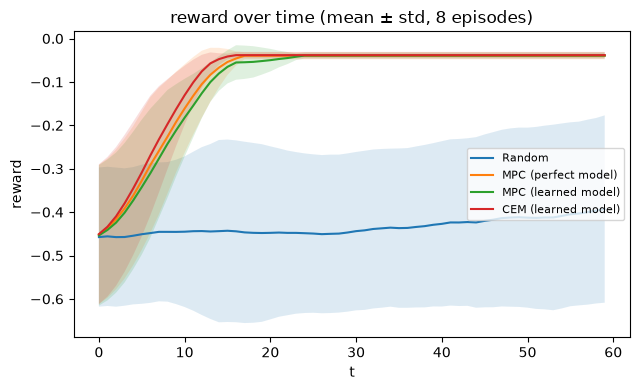

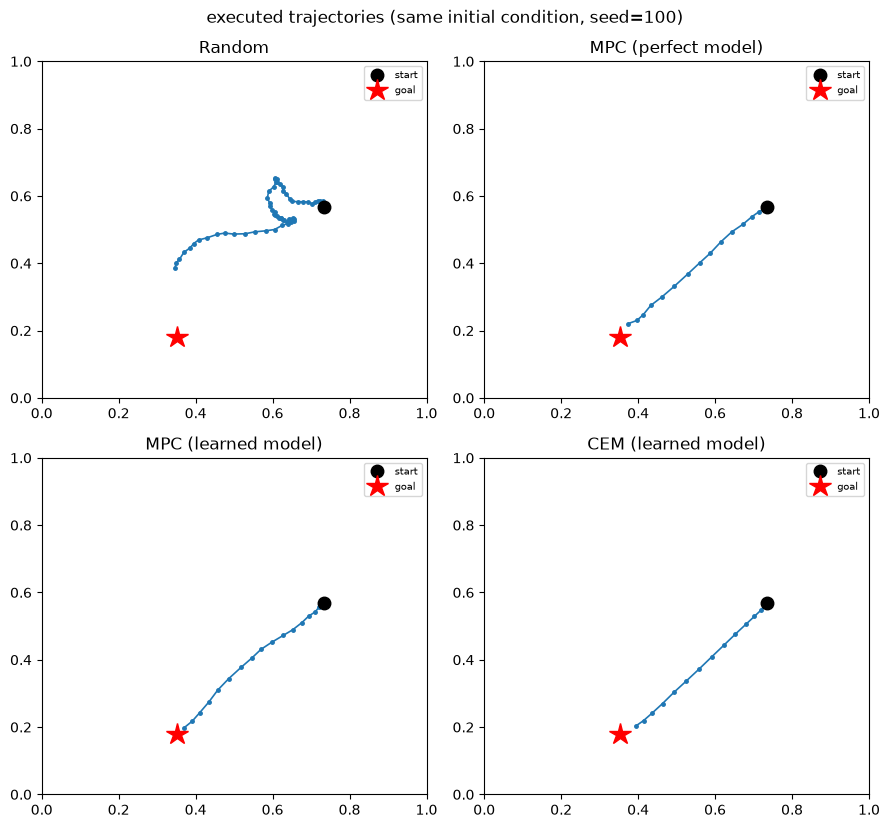

In [11]:
print(f"{'agent':24s} {'return (mean ± std)':>20s} {'success':>9s} {'avg steps':>10s}")
print("-" * 68)
for name, res in results.items():
    rets = res["rewards"].sum(axis=1)
    succ = sum(d < T_EP for d in res["dones"])
    print(f"{name:24s} {rets.mean():8.2f} ± {rets.std():6.2f} {succ:>6d}/{len(EVAL_SEEDS)}"
          f" {np.mean(res['dones']):10.1f}")

fig, ax = plt.subplots(figsize=(6.5, 4))
for name, res in results.items():
    R = res["rewards"]
    m, s = R.mean(axis=0), R.std(axis=0)
    ax.plot(m, label=name)
    ax.fill_between(range(T_EP), m - s, m + s, alpha=0.15)
ax.set(xlabel="t", ylabel="reward", title="reward over time (mean ± std, 8 episodes)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("assets/reward_curves.png", dpi=130)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(9, 8.4))
for ax, (name, res) in zip(axes.flat, results.items()):
    p = res["positions"][0]
    env_tmp = MovingBallWorld(**PARAMS)
    env_tmp.reset(seed=EVAL_SEEDS[0])
    ax.plot(p[:, 0], p[:, 1], "-o", ms=2.5, lw=1.2)
    ax.plot(*p[0], "o", color="black", ms=9, label="start")
    ax.plot(*env_tmp.goal, "*", color="red", ms=16, label="goal")
    ax.set(xlim=(0, 1), ylim=(0, 1), title=name)
    ax.legend(fontsize=7, loc="upper right")
fig.suptitle(f"executed trajectories (same initial condition, seed={EVAL_SEEDS[0]})")
plt.tight_layout()
plt.savefig("assets/agent_comparison.png", dpi=130)
plt.show()

## 8. Experiment: when is model error actually fatal?

Section 7 left a puzzle: the learned model's open-loop error accumulates to ~0.9 within 40 steps (Section 5.1), so why does closed-loop MPC (learned) nearly match the perfect model? The two short experiments in this section give the answer.

### 8.1 Open-loop vs closed-loop: when is model error fatal?

MPC replans from the real state at every step. If we **remove replanning** (plan a 40-step action sequence at t=0, then execute it blindly, open-loop, in the real environment), model error shows its true face. To push the effect to the extreme, besides the learned model we build a **corrupted model**: the analytic dynamics, but with `friction` deliberately wrong (0.98 vs the true 0.9, so the model thinks the ball is "slipperier"). This is a *systematic bias*: the planner trusts it again and again and gets led astray.

On the 6 seeds with the largest start-to-goal distance (the farther the goal, the longer the plan "runs naked" in the model), we compare five configurations. Each open-loop configuration reports two numbers: **actual** (the final distance to the goal after executing the plan for real) and **promised** (the distance the model itself predicted). The gap between the two is a direct measure of model error:

- **perfect + open-loop**: plan and reality coincide exactly; the remaining distance is just the floor set by the sample budget;
- **learned + open-loop**: the model is fairly accurate near "good trajectories", so the degradation is mild;
- **corrupted + open-loop**: the model promises arrival, but reality stops halfway. This is "model error → planning failure" in its purest form;
- **learned / corrupted + closed-loop (i.e. MPC)**: can replanning rescue the error?

selected far-apart seeds: [323, 329, 301, 326, 309, 337]
configuration              actual  promised by model
----------------------------------------------------
perfect + open              0.157              0.157


learned + open              0.120              0.127


learned + closed (MPC)      0.008                  -
corrupted + open            0.282              0.139


corrupted + closed          0.011                  -


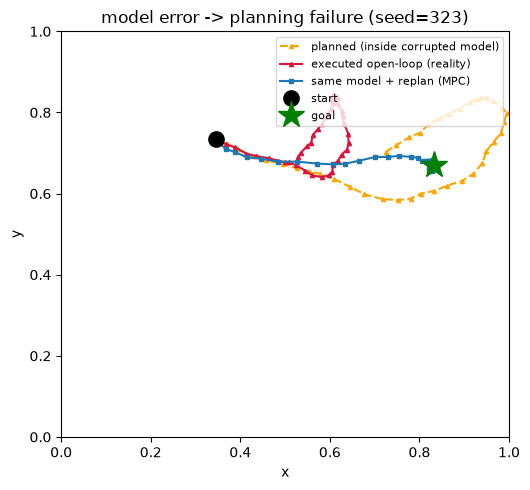

In [12]:
OL_H, OL_SAMPLES = 40, 1000

# to keep open-loop plans "exposed" long enough, pick the 6 seeds with the largest start-goal distance
_candidates = []
for _s in range(300, 340):
    _e = MovingBallWorld(**PARAMS)
    _e.reset(seed=_s)
    _candidates.append((np.linalg.norm(_e.state[:2] - _e.goal), _s))
OL_SEEDS = [s for _, s in sorted(_candidates)[-6:]]
print("selected far-apart seeds:", OL_SEEDS)

# systematically biased model: analytic dynamics, but friction deliberately wrong (0.98 vs the true 0.9, so the model thinks the ball is "slipperier")
corrupted_step = make_perfect_step(dict(PARAMS, friction=0.98))


def execute_open_loop(step_fn, seed, H=OL_H, n_samples=OL_SAMPLES):
    """plan an H-step sequence at t=0 and execute it open-loop to the end. Returns (actual trajectory, trajectory predicted inside the model)."""
    env = MovingBallWorld(**PARAMS)
    env.reset(seed=seed)
    _, info = mpc_random_shooting(step_fn, env.state, env.goal, H, n_samples, rng)
    plan = info["actions"][info["best"]]
    predicted = info["positions"][info["best"]]
    traj = [env.state[:2].copy()]
    for t in range(H):
        _, _, done, inf = env.step(plan[t])
        traj.append(inf["state"][:2].copy())
    return np.array(traj), predicted


def execute_closed_loop(step_fn, seed, T=OL_H, n_samples=OL_SAMPLES):
    """MPC that replans every step, also executed for T steps; returns the trajectory."""
    env = MovingBallWorld(**PARAMS)
    env.reset(seed=seed)
    traj = [env.state[:2].copy()]
    for t in range(T):
        a = mpc_random_shooting(step_fn, env.state, env.goal, H_PLAN, n_samples, rng)[0]
        _, _, done, inf = env.step(a)
        traj.append(inf["state"][:2].copy())
    return np.array(traj)


def dist_to_goal(pos, seed):
    env = MovingBallWorld(**PARAMS)
    env.reset(seed=seed)
    return float(np.linalg.norm(pos - env.goal))


configs = [("perfect + open", perfect_step, "open"),
           ("learned + open", learned_step, "open"),
           ("learned + closed (MPC)", learned_step, "closed"),
           ("corrupted + open", corrupted_step, "open"),
           ("corrupted + closed", corrupted_step, "closed")]
print(f"{'configuration':24s} {'actual':>8s} {'promised by model':>18s}")
print("-" * 52)
for name, sf, mode in configs:
    da, dp = [], []
    for seed in OL_SEEDS:
        if mode == "open":
            traj, pred = execute_open_loop(sf, seed)
            dp.append(dist_to_goal(pred[-1], seed))
        else:
            traj = execute_closed_loop(sf, seed)
        da.append(dist_to_goal(traj[-1], seed))
    promised = f"{np.mean(dp):8.3f}" if dp else "       -"
    print(f"{name:24s} {np.mean(da):8.3f} {promised:>18s}")

# trajectory illustration: the corrupted model's "promise vs reality" on one seed
demo_seed = OL_SEEDS[0]
traj_open, pred_open = execute_open_loop(corrupted_step, demo_seed)
traj_closed = execute_closed_loop(corrupted_step, demo_seed)
env_tmp = MovingBallWorld(**PARAMS)
env_tmp.reset(seed=demo_seed)

fig, ax = plt.subplots(figsize=(5.4, 5))
ax.plot(pred_open[:, 0], pred_open[:, 1], "--^", ms=3, color="orange",
        label="planned (inside corrupted model)")
ax.plot(traj_open[:, 0], traj_open[:, 1], "-^", ms=3, color="crimson",
        label="executed open-loop (reality)")
ax.plot(traj_closed[:, 0], traj_closed[:, 1], "-s", ms=3, color="tab:blue",
        label="same model + replan (MPC)")
ax.plot(*traj_open[0], "o", color="black", ms=11, label="start")
ax.plot(*env_tmp.goal, "*", color="green", ms=20, label="goal")
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="x", ylabel="y",
       title=f"model error -> planning failure (seed={demo_seed})")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig("assets/open_vs_closed.png", dpi=130)
plt.show()

**Typical results**: in the open-loop group, the perfect model's actual and promised distances are identical (the plan is reality); the learned model's promise and reality stay fairly close (both around 0.1–0.16); the corrupted model promises ~0.11–0.14 but actually ends at ~0.28. The promise cannot be kept: that is "model error → planning failure". In the closed-loop (MPC) group, however, **the same corrupted model, as long as it replans every step, immediately gets back to a final distance of ~0.01, better than any open-loop plan, even the perfect model's**.

**Conclusion: model error is not eliminated; it is continuously corrected by the receding-horizon feedback loop.** That is exactly why Dreamer and TD-MPC train in imagination but always make decisions in closed loop with real observations. Conversely, once the feedback loop is cut (open-loop execution, or a real world that cannot be observed often), the model's accuracy directly determines the planner's ceiling. Lab 10 returns to this question.

### 8.2 Planning horizon: the trade-off with sample budget

Intuitively a longer horizon sees farther, but in practice H and the **sample budget** constrain each other: the action-sequence space that N candidates must cover grows exponentially with H (on the order of $9^{H}$ here), so with N fixed, the longer the horizon, the fewer samples each "useful search direction" gets.

Below we sweep `H ∈ {1, 2, 4, 8, 16, 32}` (N fixed at 200) and run MPC with both the perfect and the learned model. **Expectation**: in this simple task, where the reward itself points at the goal, short-horizon greediness is already good enough; as H grows further, both models slowly degrade because the samples get diluted, and the learned model does not collapse despite looking farther ahead, because closed-loop replanning (the conclusion of 8.1) protects it.

H= 1   perfect    -4.10   learned    -4.33   (1s elapsed)


H= 2   perfect    -3.76   learned    -3.97   (2s elapsed)


H= 4   perfect    -4.13   learned    -4.45   (6s elapsed)


H= 8   perfect    -4.66   learned    -4.55   (15s elapsed)


H=16   perfect    -5.11   learned    -5.15   (34s elapsed)


H=32   perfect    -5.93   learned    -5.81   (79s elapsed)


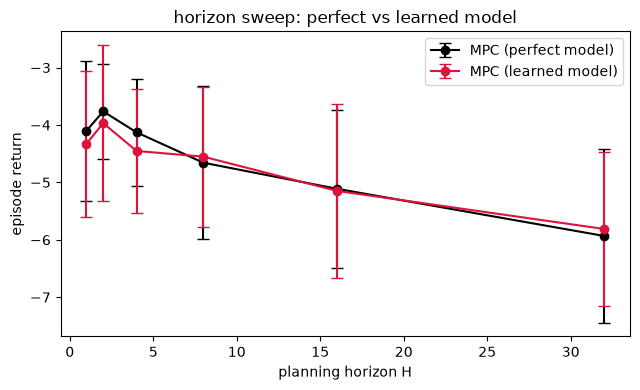


total notebook runtime: 845.1s | peak memory (kernel): 787 MB


In [13]:
H_LIST = [1, 2, 4, 8, 16, 32]
SWEEP_SEEDS = [200 + i for i in range(6)]

sweep = {"perfect": [], "learned": []}
t0 = time.time()
for H in H_LIST:
    for kind, step_fn in [("perfect", perfect_step), ("learned", learned_step)]:
        rets = []
        for seed in SWEEP_SEEDS:
            policy = lambda s, g, H=H, sf=step_fn: mpc_random_shooting(sf, s, g, H, 200, rng)[0]
            r, _, _ = run_episode(policy, seed=seed)
            rets.append(r.sum())
        sweep[kind].append((np.mean(rets), np.std(rets)))
    print(f"H={H:2d}   perfect {sweep['perfect'][-1][0]:8.2f}   learned {sweep['learned'][-1][0]:8.2f}"
          f"   ({time.time() - t0:.0f}s elapsed)")

fig, ax = plt.subplots(figsize=(6.5, 4))
for kind, color in [("perfect", "black"), ("learned", "crimson")]:
    m = [v[0] for v in sweep[kind]]
    s = [v[1] for v in sweep[kind]]
    ax.errorbar(H_LIST, m, yerr=s, marker="o", capsize=4, color=color,
                label=f"MPC ({kind} model)")
ax.set(xlabel="planning horizon H", ylabel="episode return",
       title="horizon sweep: perfect vs learned model")
ax.legend()
plt.tight_layout()
plt.savefig("assets/horizon_sweep.png", dpi=130)
plt.show()

peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
peak_mb = peak / 1e6 if platform.system() == "Darwin" else peak / 1e3
print(f"\ntotal notebook runtime: {time.time() - T0:.1f}s | peak memory (kernel): {peak_mb:.0f} MB")

## 9. Questions

1. **Why is random shooting good enough for this task?** The action has only 2 dimensions and the horizon is only a dozen or so steps. If the action dimension became 10 and the horizon 100, how would the "hit rate" of uniform sampling change? What problem do CEM / MPPI actually alleviate?
2. **What assumption is hidden in CEM's elite-mean update?** If the reward landscape is multi-modal (for example, going around the left wall and around the right wall are equally good), what does the single-Gaussian assumption lead to?
3. **What makes up the gap between MPC (learned) and MPC (perfect)?** One-step error, error accumulation, or the planner over-exploiting model errors (model exploitation, i.e. finding actions that "fool" the model)? How would you design an experiment to tell them apart?
4. **If replanning happened only every 5 steps** (executing the first 5 actions of the best sequence open-loop), which degrades more, the perfect model or the learned model? Why?

### ✏️ Exercise 1 — A smaller sample budget

Lower `N_SAMPLES` from 256 to 32 and rerun the comparison in Section 7. Which agent degrades the most? Does CEM's sample-efficiency advantage over random shooting become more visible?

In [14]:
# YOUR CODE HERE
# hint: policy = lambda s, g: mpc_random_shooting(learned_step, s, g, H_PLAN, 32, rng)[0]
#       then evaluate with run_episode on EVAL_SEEDS and compare with the N_SAMPLES=256 results
pass

### ✏️ Exercise 2 — A noisy model (model uncertainty)

Add Gaussian noise to the output of `learned_step` (for example `+ 0.02 * np.random.randn(*states.shape)`) and rerun the evaluation. Watch how model uncertainty erodes planning. This is exactly the problem PETS addresses by modeling uncertainty explicitly with a probabilistic ensemble.

In [15]:
# YOUR CODE HERE
# hint: def noisy_step(states, actions):
#           return learned_step(states, actions) + 0.02 * np.random.randn(*np.asarray(states).shape)
#       then build a policy from noisy_step and call run_episode
pass

## 10. Takeaways

- **A world model moves trial and error into imagination**: planning = rolling out futures in bulk inside the model and ranking them by predicted reward. MPC / CEM need no gradients and no trained policy network; the model is plug and play.
- **The receding horizon is a cheap and powerful error-correction mechanism**: the controlled experiment in 8.1 shows it directly. With the same learned model, executing a plan open-loop fails, while closed-loop step-by-step replanning nearly matches the perfect model. The feedback loop confines model error to a single step.
- **Model error is the Achilles' heel of model-based methods**: the open-loop error-accumulation curve (5.1), the predicted-vs-actual trajectory separation (6.1), and the failed execution of open-loop plans (8.1) are three sides of the same fact: **once correction from real feedback is lost, the planner's ceiling is set by the model's accuracy**.
- **Horizon and sample budget constrain each other**: with N fixed, the action-sequence space grows exponentially with H, so a longer horizon dilutes the search; the horizon has to be chosen together with the planner's sample efficiency.
- **Next**: when the state is no longer a clean `(x, y, vx, vy)` but pixels, planning has to happen in **latent space**. Move this lab's CEM onto the RSSM latent from Lab 3 and you have essentially reproduced **PlaNet**; add a learned value function and a policy prior and you get **TD-MPC / Dreamer**. Lab 10 continues this thread.